## **P451 Intro-A: EM Pulses**

---


Last updated  7 Aug., 2026 15:40  D. V. Baxter


**Summary:**

---


**Physics:** Signals propagate along coaxial cables with a speed that depends on the dielectric between the inner and outer conductors, and the cables act with a characteristic impedance when connected to external circuits.
**Applications:** Coaxial cables are used throughout experimental science as they are very useful for transmitting signals with relatively low loss and little susceptibility to interference from sources of noise. In this lab, you will learn about some of the characteristics of such cables (and that they are not all identical).
**Technique:** You will learn how to properly terminate signal cables to avoid erroneous results when working with electronic circuits.  This lab also gives you a chance to explore fitting data to a user-defined function and judging quality of the fit based on $\chi^2$. You will not submit a formal report for this lab, but your logbook entries should address the questions in section 4 directly, including a assessment of the two different models for describing the fit to the reflection data in question 6.

**Introduction:**

---

Coaxial cables operate as wave guides in the TEM mode and effectively have inductive, capacitive, and resistive elements.  The EM waves propagate through the dielectric that fills the space between the center conductor and the outer shield.  The physical properties of the cable give it a characteristic impedance that is tied to the inductance and capacitance per unit length of the cable.  Most cables we will encounter in the lab have a 50~$\Omega$ impedance.  Note that this impedance is independent of length and cannot be interpreted as a simple resistance between the center conductor and ground.  In fact, in the DC limit there is virtually infinite impedance between the center conductor and ground.  It is important that loads connected to the end of the cable have an input impedance that matches that of the cable.  Otherwise, a reflection will be generated at the boundary between the cable and the load.  The coefficient of reflection $\Gamma$ is given by


\begin{equation}
\Gamma = \frac{Z_L - Z_c }{Z_L + Z_c},
\end{equation}
where $Z_L$ and $Z_c$ are the load input impedance and cable impedance, respectively.  The impedances are said to be "matched" when $Z_L = Z_c$.  Impedance mismatches can generate spurious pules from reflections that are problematic in electronic circuits.  Read the detailed discussion of coaxial cables outlined in Experiment 1 of Ref.~\cite{preston} before beginning this lab.



Setup and Equipment:

---
n this lab we will concentrate on cables terminated with standard BNC (Berkeley Nucleonics Corporation) connectors (twist-lok action). In other labs in this course, you may make use of thinner cables terminated with smaller "Lemo" connectors (with a push-pull locking action). The principles you learn in this lab apply to both types of cable (in particular, they typically share the same nominal characteristic impedance even though the cables look very different physically). For this experiment you will need the following:


\item pulse generator
\item oscilloscope
\item coaxial cables of different langths and types
\item various BNC connectors to connect cables, instruments, and resistances
\item resistance decade box and/or resistors.


Connect the output of the pulse generator to the scope using a T connector.  The remaining open end of the T should be connected to the cable under test. The scope will be used to examine both the initial pulse and the reflected pulse.  The duration of the pulse should be much shorter than the propagation time through the test cable, and the time between pulses should be much longer than the propagation time through the test cable.




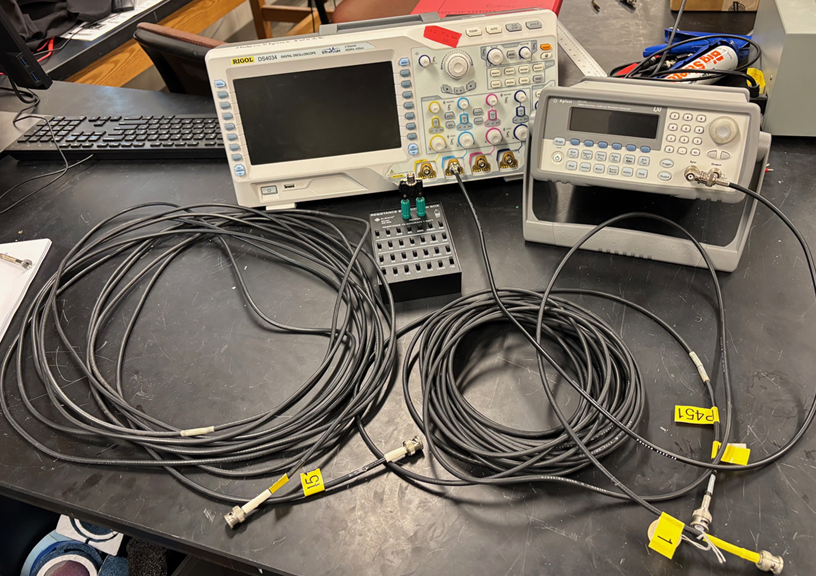

Fig. 1  The equipment used for this lab consists of a signal generator capable of producing pulses of duration 20ns or less, a scope, several coax cables and various resistors to be used in "terminating" the long cables.

**Experiments:**

---

For this lab, you do not need to write a formal report -- simply address the discussion points itemized below in your logbook (or in a LaTeX-produced pdf if you want practice with that).

1.  Measure the signal propagation velocity for one of the cables (say $A$; note its model number in your logbook).  This can be done by reflecting a pulse from the open end of the cable and measuring the time delay as well as the physical length of the cable.  What value do you get for the velocity and what is your estimate of the uncertainty on that measurement? Think about how you determine the time between the initial and reflected pulses and how you measure the length! Does it matter how you do these? Do you notice any differences between the incident and reflected pulses? What might those differences tell you? These considerations all have an impact on your uncertainties. Repeat this exercise for the other cable ($B$). Do you get a different velocity for the second cable (see the next exercise to explore what this really means)?

2. What is the probability that two cables of the same type will have a velocity difference $v_A - v_B$ at least as great as the one that you measured?  To determine this, first carefully derive the errors on the measured propagation velocities and, from these, compute the error on $v_A - v_B$.  For two cables of the same type, one would expect $v_A - v_B$ to be a Gaussian distribution with an average of zero.  Assuming that the standard deviation of this Gaussian is your estimated error bar for $v_A-v_B$, you can compute the probability of a fluctuation from zero that is at least as large as the deviation you observe.  Can you conclude the propagation velocities in the cables are likely different?  Do the data sheets (attached) support this claim?

3. Terminate the coaxial cable with a variety if different load impedances $Z_L$.  Study the ratio of reflected to incident pulses as a function of load impedance.

4. Make a plot of reflection coefficient as a function of the load impedance.  Fit these data to the expected theoretical form with the impedance of the cable as a free parameter.  Does the fit value of the cable impedance match your expectation?

5. Discuss the quality of the fit.  What is the $\chi^2/d.o.f.$ and how does its value match your expectation?

6. Modify the fit function to include the effects of attenuation in the cable and refit the data.  Does the fit value of $Z_C$ change?  How much does the fit $\chi^2/d.o.f.$ improve?  Estimate the attenuation length of the cable from the results of the fit and compare your result to the information on the data sheet.



**References**

---
1. D. W. Preston and E. R. Deitz, "*The Art of Experimental Physics*", Wiley, New York (1991).
2. R. W. Leo, "*Techniques for Nuclear and Particle Physics Experiments*", Springer (1987).


In [1]:
# function describing the reflection from a cable of impedence Z_C with load Z_L
# with attenuation, student version should remove the attenuation features
def func(ZL, *popt):
  """ The expected ratio of reflected signal / input signal
  Parameters
  ----------
  ZL - float
    Load resistance in ohms
  popt[0] - float
    Cable impedance in ohms (Z_c) (written as an array to facilitate adding
    additional parameter(s) to the model if desired)

  Returns: float
    The ratio of reflected wave amplitude / incident wave amplitude
  """
  ZC=popt[0]
  return (ZL-ZC)/(ZL+ZC)

In [ ]:
import numpy  as np
import pandas as pd
df = pd.read_csv('smyrichinsky_cable_2.txt')
#
# The measured reflection coefficient and its error. Percent errors add in
# quardature for ratios
#
rl        = df['resistance_ohms']
gamma     = df['incident_wave_ampl']/df['reflected_wave_ampl']
sig_gamma = abs(gamma)*np.sqrt( (df['reflected_wave_error']/df['reflected_wave_ampl'])**2 + (df['incident_wave_error']/df['incident_wave_ampl'])**2 )
#print(rl, gamma, sig_gamma)

TypeError: unsupported operand type(s) for /: 'str' and 'float'

In [ ]:
#
# Make a curve fit to the data
#
from scipy.optimize import curve_fit
#
# "guess" is a variable to hold initial values used in the fitting function.
# There should be one guess for every parameter to be fit. In the initial
# version, there is only a single parameter (Z_C). When students modify the
# function to include signal loss, there should be two parameters to fit.
#
guess = [50]
popt, pcov = curve_fit(func,                # the fit function
                       rl,                  # the x values
                       gamma,               # the measurements at each rl value
                       sigma=sig_gamma,     # error bars on the data points
                       p0=guess,            # initial guess at parameter values
                       absolute_sigma=True) # the errors are not relative weights
perr     = np.sqrt(np.diag(pcov))
best_fit = func(rl,*popt)
chisq    = np.sum(((gamma-best_fit)/sig_gamma)**2)
ndof     = len(gamma)-len(guess)
print('Best fit: Zc = %f +- %f ohms'%(popt[0],perr[0]))
#print('Best fit: Attn = %f +/-%f'%(popt[1],perr[1]))
print('chisq = %f / %d'%(chisq,ndof))

Best fit: Zc = 60.046922 +- 0.544601 ohms
chisq = 2590.748316 / 12


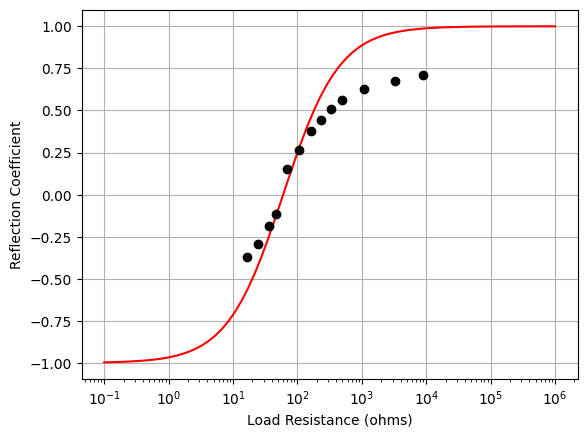

In [ ]:
#
# Plot the results
#
import matplotlib.pyplot as plt
plt.errorbar(rl, gamma, yerr=sig_gamma, fmt='o', ecolor='black', color='black')
rl_smooth       = 10**(np.linspace(-1,6,70))
best_fit_smooth = func(rl_smooth,*popt)
plt.plot(rl_smooth, best_fit_smooth, 'r')
plt.xlabel('Load Resistance (ohms)')
plt.ylabel('Reflection Coefficient')
plt.xscale("log")
plt.grid()

**Appendix:**

---


Key pages from the data sheets for the two cables used in this experiment. The full data sheets are available in the lab, online, and/or on the course canvas site.

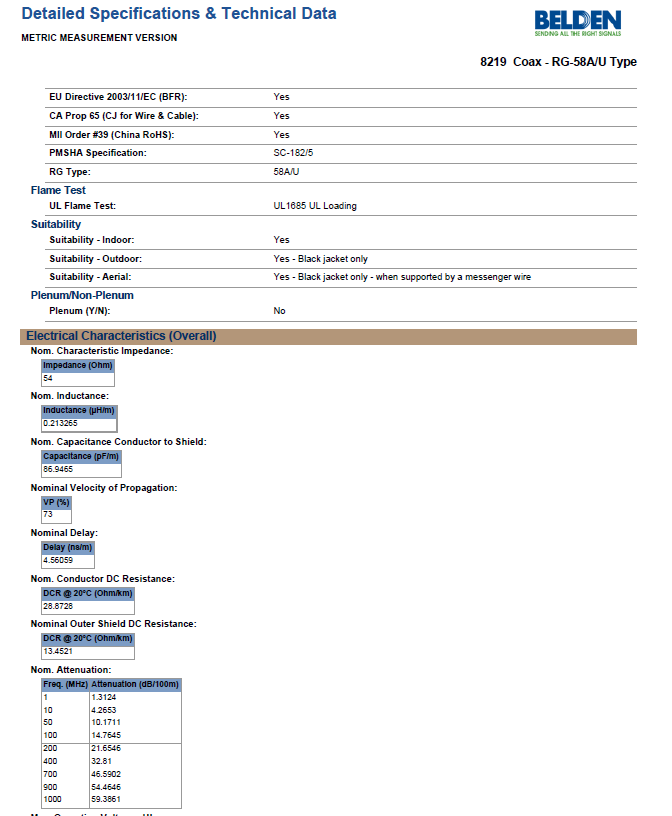

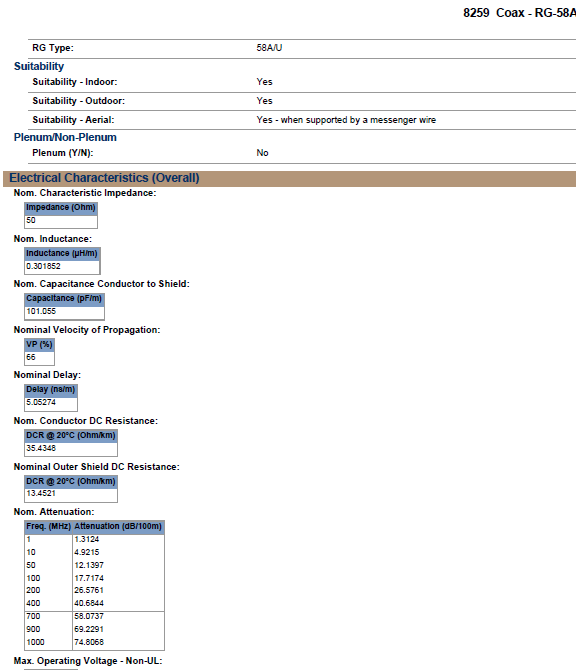